# Análisis interactivo · football-analytics

Notebook exploratorio sobre el mismo pipeline que corremos por CLI (`src/fetch_football_data.py`,
`src/team_strength.py`, `src/poisson_model.py`, `src/predict_matchday.py`).

Sirve para explorar los datos celda por celda, ver tablas completas y graficar sin
tener que leer texto plano en la terminal.


In [1]:
import sys
from pathlib import Path

# El notebook vive en football-analytics/notebooks/, subimos un nivel para importar "src".
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

from src import config
from src.team_strength import team_strength_for_competition, confidence_note
from src.poisson_model import predict_match
from src.predict_matchday import upcoming_fixtures

print("Proyecto:", PROJECT_ROOT)
print("¿API key cargada?", "sí" if config.FOOTBALL_DATA_API_KEY else "no (revisa el .env)")


Proyecto: c:\Users\Castr\OneDrive\Documents\Laura Personal\Daxus\Asistentes de IA\Pruebas Claude\football-analytics
¿API key cargada? sí


## 1. Qué datos hay descargados

In [2]:
resumen = []
for code_, nombre in config.COMPETITIONS.items():
    for season in (2025, 2026):
        path = config.PROCESSED_DIR / f"matches_{code_}_{season}.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path)
        resumen.append({
            "competicion": nombre,
            "codigo": code_,
            "temporada": season,
            "partidos": len(df),
            "finalizados": (df["status"] == "FINISHED").sum(),
            "pendientes": (df["status"].isin(["SCHEDULED", "TIMED"])).sum(),
        })
pd.DataFrame(resumen)


,competicion,codigo,temporada,partidos,finalizados,pendientes
0,Premier League,PL,2025,380,380,0
1,Premier League,PL,2026,380,30,350
2,LaLiga,PD,2025,380,380,0
3,LaLiga,PD,2026,380,42,338
4,Serie A,SA,2025,380,380,0
5,Serie A,SA,2026,380,31,349
6,Bundesliga,BL1,2025,306,306,0
7,Bundesliga,BL1,2026,306,19,287
8,Ligue 1,FL1,2025,306,305,0
9,Ligue 1,FL1,2026,306,28,278


## 2. Fuerza de equipos

Cambia `COMPETENCIA` por cualquier código de `config.COMPETITIONS` (`PL`, `PD`, `SA`, `BL1`, `FL1`, `CL`).


In [3]:
COMPETENCIA = "PL"

strength = team_strength_for_competition(COMPETENCIA, seasons=[2026, 2025])
tabla = strength[["home_played", "away_played", "attack_home", "defense_home", "attack_away", "defense_away"]]
tabla.sort_values("attack_home", ascending=False).round(2)


,home_played,away_played,attack_home,defense_home,attack_away,defense_away
home_team,,,,,,
Manchester City FC,21,20,1.43,0.64,1.41,0.75
Manchester United FC,20,21,1.38,1.05,1.21,0.94
Arsenal FC,21,20,1.38,0.53,1.23,0.58
Newcastle United FC,21,20,1.21,1.28,0.81,0.84
Liverpool FC,20,21,1.15,0.91,1.25,1.08
Brentford FC,21,20,1.13,0.87,0.95,1.04
Brighton & Hove Albion FC,21,20,1.08,0.84,1.02,0.98
Fulham FC,21,20,1.05,1.01,0.73,1.04
Aston Villa FC,20,21,1.04,0.95,0.94,0.97


### Ranking visual: fuerza de ataque en casa

Un vistazo rápido de qué tan por encima o por debajo del promedio de liga (1.0) ataca cada equipo como local.


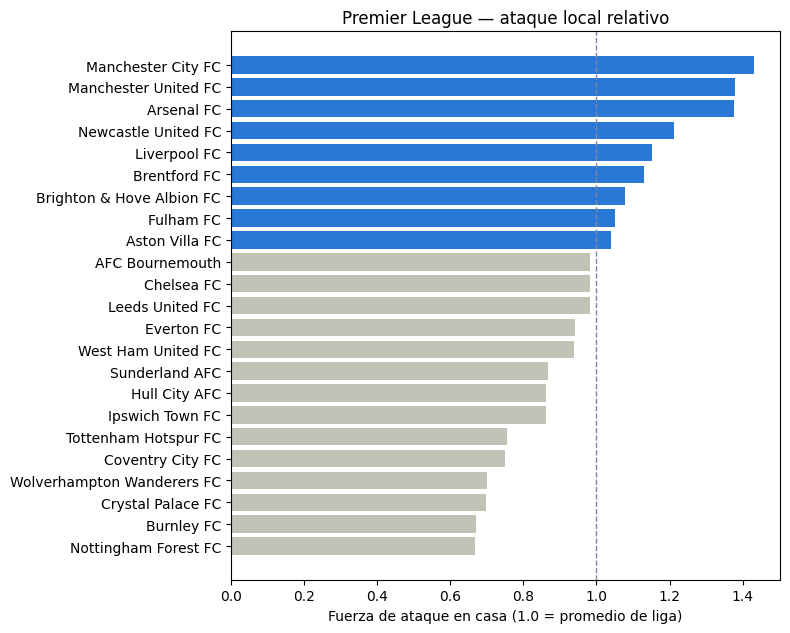

In [4]:
top = tabla.sort_values("attack_home", ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(top) * 0.28)))
colors = ["#2a78d6" if v >= 1 else "#c3c2b7" for v in top["attack_home"]]
ax.barh(top.index[::-1], top["attack_home"][::-1], color=colors[::-1])
ax.axvline(1.0, color="#7c86a0", linestyle="--", linewidth=1)
ax.set_xlabel("Fuerza de ataque en casa (1.0 = promedio de liga)")
ax.set_title(f"{config.COMPETITIONS[COMPETENCIA]} — ataque local relativo")
plt.tight_layout()
plt.show()


## 3. Predicciones de la próxima jornada

Cambia `JORNADA` según corresponda a la competencia elegida arriba.


In [5]:
JORNADA = 4  # ajusta según la competencia y la fecha

fixtures = upcoming_fixtures(COMPETENCIA, season=2026, matchday=JORNADA)
filas = []
for _, row in fixtures.iterrows():
    try:
        pred = predict_match(strength, row["home_team"], row["away_team"])
    except KeyError:
        continue
    nota = confidence_note(strength, row["home_team"], row["away_team"])
    filas.append({
        "local": row["home_team"], "visitante": row["away_team"],
        "xG_local": round(pred.home_xg, 2), "xG_visitante": round(pred.away_xg, 2),
        "% local": round(pred.home_win * 100, 1),
        "% empate": round(pred.draw * 100, 1),
        "% visitante": round(pred.away_win * 100, 1),
        "over_2.5": round(pred.over_2_5 * 100, 1),
        "btts": round(pred.btts * 100, 1),
        "marcador_top": f"{pred.top_scorelines(1)[0][0][0]}-{pred.top_scorelines(1)[0][0][1]}",
        "baja_confianza": nota is not None,
    })

predicciones = pd.DataFrame(filas)
predicciones


,local,visitante,xG_local,xG_visitante,% local,% empate,% visitante,over_2.5,btts,marcador_top,baja_confianza
0,Crystal Palace FC,Ipswich Town FC,1.67,1.54,41.1,23.3,35.6,62.4,63.9,1-1,True
1,Liverpool FC,Fulham FC,1.83,0.82,61.4,22.3,16.3,49.5,47.0,1-0,False
2,Aston Villa FC,Nottingham Forest FC,1.56,1.39,41.7,24.4,33.9,56.5,59.3,1-1,False
3,AFC Bournemouth,Brentford FC,1.56,1.02,50.0,25.4,24.6,47.6,50.4,1-1,False
4,Chelsea FC,Hull City AFC,1.13,1.31,31.9,27.2,40.9,44.1,49.5,1-1,True
5,Tottenham Hotspur FC,Everton FC,0.94,1.45,24.3,26.6,49.1,42.8,46.7,0-1,False
6,Sunderland AFC,Arsenal FC,0.78,1.27,22.8,29.2,48.0,33.5,38.8,0-1,False
7,Coventry City FC,Brighton & Hove Albion FC,1.13,1.19,34.4,28.2,37.4,40.9,47.0,1-1,True
8,Manchester United FC,Manchester City FC,1.60,1.82,34.2,22.5,43.4,66.3,66.8,1-1,False
9,Leeds United FC,Newcastle United FC,1.26,0.90,44.8,28.8,26.4,36.7,42.5,1-0,False


### Visualización: probabilidad 1X2 por partido

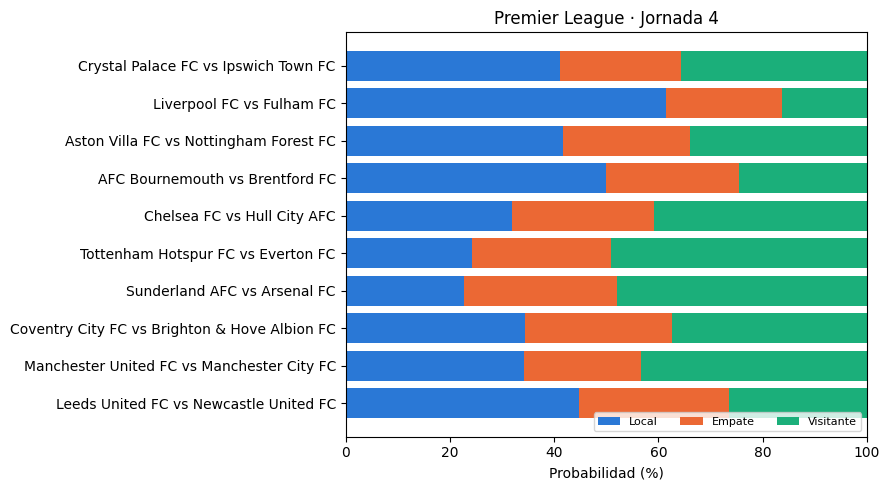

In [6]:
if predicciones.empty:
    print("No hay partidos programados para esa competencia/jornada.")
else:
    orden = predicciones.assign(etiqueta=predicciones["local"] + " vs " + predicciones["visitante"])
    fig, ax = plt.subplots(figsize=(9, max(3, len(orden) * 0.5)))
    y = range(len(orden))
    ax.barh(y, orden["% local"], color="#2a78d6", label="Local")
    ax.barh(y, orden["% empate"], left=orden["% local"], color="#eb6834", label="Empate")
    ax.barh(y, orden["% visitante"], left=orden["% local"] + orden["% empate"], color="#1baf7a", label="Visitante")
    ax.set_yticks(list(y))
    ax.set_yticklabels(orden["etiqueta"])
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("Probabilidad (%)")
    ax.set_title(f"{config.COMPETITIONS[COMPETENCIA]} · Jornada {JORNADA}")
    ax.legend(loc="lower right", ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


## 4. Calibración del proyecto

Lee `data/tracking/predictions_log.csv`: predicciones logueadas antes de cada partido y
resueltas después contra el resultado real. Mide si el modelo está bien calibrado
(¿cuando dice 70%, gana ~70% de las veces?).


In [7]:
log_path = config.ROOT_DIR / "data" / "tracking" / "predictions_log.csv"
log = pd.read_csv(log_path)
resueltas = log[log["status"] == "resolved"].copy()
resueltas["hit"] = resueltas["hit"].astype(bool)

print(f"{len(resueltas)} predicciones resueltas de {len(log)} logueadas.")
if not resueltas.empty:
    print(f"Acierto general: {resueltas['hit'].mean():.0%}")
resueltas


18 predicciones resueltas de 62 logueadas.
Acierto general: 72%


,logged_at,resolved_at,competition,season,matchday,home_team,away_team,source,pred_home_pct,pred_draw_pct,...,away_xg,over_2_5_pct,btts_pct,low_confidence,status,actual_home_goals,actual_away_goals,actual_result,favored_side,hit
0,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,AEK Athens,LASK,dashboard_v1_qualitative,50.0,28.0,...,NaN,NaN,NaN,False,resolved,1.0,0.0,H,H,True
1,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Club Brugge,Aston Villa,dashboard_v1_qualitative,38.0,27.0,...,NaN,NaN,NaN,False,resolved,2.0,3.0,A,H,False
2,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Borussia Dortmund,Villarreal,dashboard_v1_qualitative,52.0,24.0,...,NaN,NaN,NaN,False,resolved,3.0,2.0,H,H,True
3,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Porto,Manchester City,dashboard_v1_qualitative,22.0,23.0,...,NaN,NaN,NaN,False,resolved,0.0,2.0,A,A,True
4,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Lille,Real Betis,dashboard_v1_qualitative,39.0,27.0,...,NaN,NaN,NaN,False,resolved,2.0,3.0,A,H,False
5,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Real Madrid,Inter,dashboard_v1_qualitative,50.0,27.0,...,NaN,NaN,NaN,False,resolved,2.0,1.0,H,H,True
6,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Barcelona,Feyenoord,dashboard_v1_qualitative,68.0,19.0,...,NaN,NaN,NaN,False,resolved,5.0,1.0,H,H,True
7,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Stuttgart,Viking,dashboard_v1_qualitative,66.0,20.0,...,NaN,NaN,NaN,False,resolved,3.0,1.0,H,H,True
8,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Liverpool,Atlético de Madrid,dashboard_v1_qualitative,48.0,28.0,...,NaN,NaN,NaN,False,resolved,2.0,1.0,H,H,True
9,2026-09-07T00:00:00Z,2026-09-11T00:00:00Z,CL,2026,1,Paris Saint-Germain,Slovan Bratislava,dashboard_v1_qualitative,62.0,20.0,...,NaN,NaN,NaN,False,resolved,6.0,1.0,H,H,True


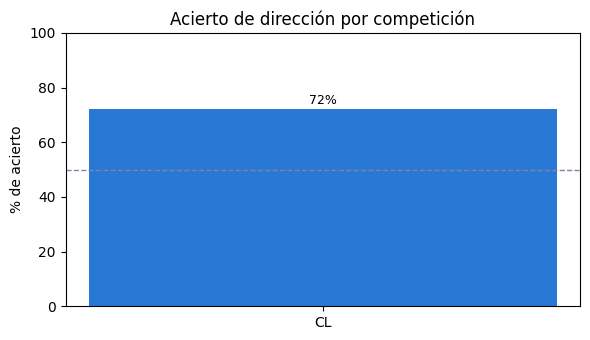

In [8]:
if not resueltas.empty:
    por_comp = resueltas.groupby("competition")["hit"].agg(aciertos="sum", total="count")
    por_comp["tasa"] = (por_comp["aciertos"] / por_comp["total"] * 100).round(0)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(por_comp.index, por_comp["tasa"], color="#2a78d6")
    ax.axhline(50, color="#7c86a0", linestyle="--", linewidth=1, label="33% = azar en 1X2")
    ax.set_ylabel("% de acierto")
    ax.set_ylim(0, 100)
    ax.set_title("Acierto de dirección por competición")
    for i, v in enumerate(por_comp["tasa"]):
        ax.text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Todavía no hay predicciones resueltas.")
